<a href="https://colab.research.google.com/github/rajeev198886/SKS-Data-Science-Internship-2026/blob/main/Model_Evaluation_and_Interpretation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Telco_Customer_Churn_Dataset.csv.csv to Telco_Customer_Churn_Dataset.csv.csv


In [7]:
data = pd.read_csv("Telco_Customer_Churn_Dataset.csv.csv")

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

data["TotalCharges"].fillna(data["TotalCharges"].mean(), inplace=True)

data.drop("customerID", axis=1, inplace=True)

/tmp/ipykernel_16723/801459076.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["TotalCharges"].fillna(data["TotalCharges"].mean(), inplace=True)


In [9]:
encoder = LabelEncoder()

for column in data.columns:
    if data[column].dtype=="object":
        data[column]=encoder.fit_transform(data[column])

In [10]:
X = data.drop("Churn", axis=1)

y = data["Churn"]

In [11]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [12]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [13]:
prediction=model.predict(X_test)

In [14]:
print("Accuracy :",accuracy_score(y_test,prediction))

print("Precision :",precision_score(y_test,prediction))

print("Recall :",recall_score(y_test,prediction))

print("F1 Score :",f1_score(y_test,prediction))

Accuracy : 0.8168914123491838
Precision : 0.6802507836990596
Recall : 0.5817694369973191
F1 Score : 0.6271676300578035


In [15]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



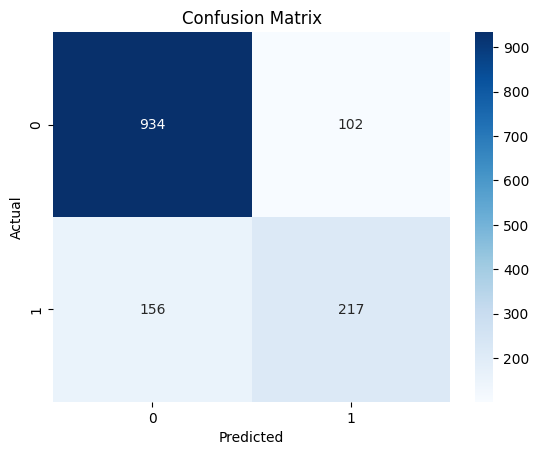

In [16]:
cm=confusion_matrix(y_test,prediction)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [17]:
importance=pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":model.coef_[0]

})

importance

,Feature,Coefficient
0,gender,-0.051361
1,SeniorCitizen,0.176654
2,Partner,0.072445
3,Dependents,-0.190332
4,tenure,-0.054148
5,PhoneService,-1.019509
6,MultipleLines,0.072570
7,InternetService,0.228791
8,OnlineSecurity,-0.292882
9,OnlineBackup,-0.155849


In [18]:
importance=importance.sort_values(
    by="Coefficient",
    ascending=False
)

importance

,Feature,Coefficient
15,PaperlessBilling,0.354943
7,InternetService,0.228791
1,SeniorCitizen,0.176654
6,MultipleLines,0.072570
2,Partner,0.072445
16,PaymentMethod,0.058922
13,StreamingMovies,0.035192
17,MonthlyCharges,0.022204
18,TotalCharges,0.000270
12,StreamingTV,-0.013760


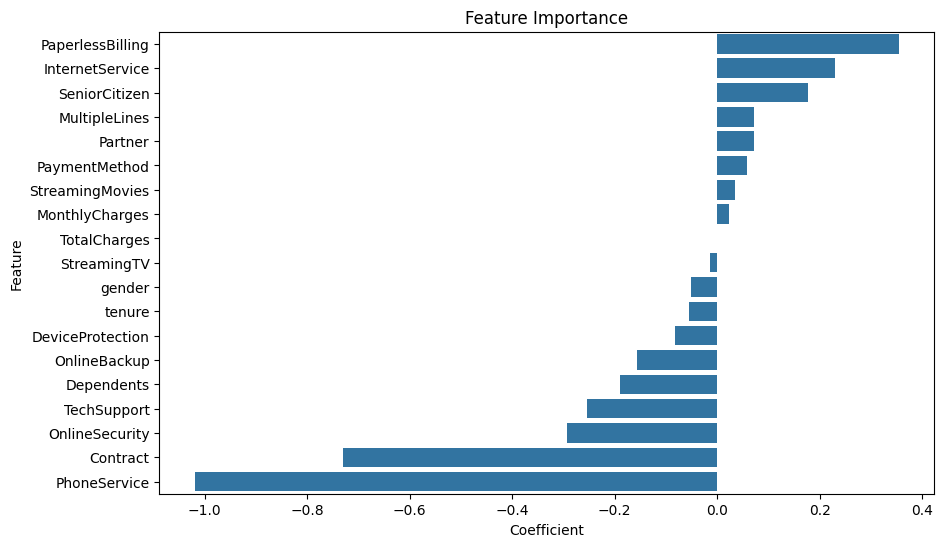

In [19]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

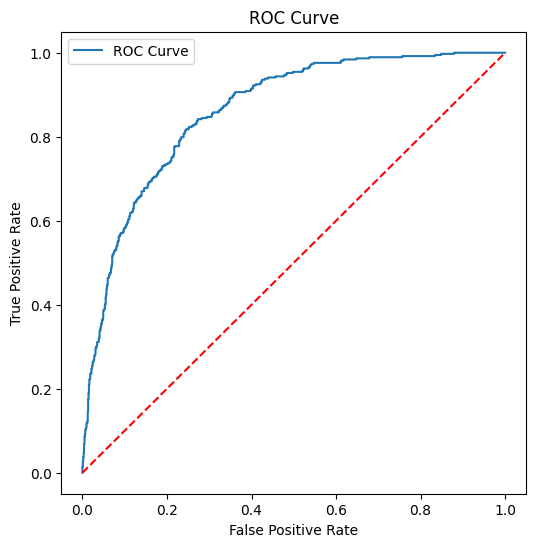

In [20]:
probability=model.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(
    y_test,
    probability
)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr,label="ROC Curve")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [21]:
auc=roc_auc_score(
    y_test,
    probability
)

print("AUC Score :",auc)

AUC Score : 0.8613933255354167


In [22]:
print("Accuracy :",accuracy_score(y_test,prediction))

print("Precision :",precision_score(y_test,prediction))

print("Recall :",recall_score(y_test,prediction))

print("F1 Score :",f1_score(y_test,prediction))

print("AUC Score :",auc)

Accuracy : 0.8168914123491838
Precision : 0.6802507836990596
Recall : 0.5817694369973191
F1 Score : 0.6271676300578035
AUC Score : 0.8613933255354167


In [23]:
output=X_test.copy()

output["Actual"]=y_test

output["Prediction"]=prediction

output.to_csv(
    "Task5_Model_Evaluation_Output.csv",
    index=False
)

print("Output Saved Successfully")

Output Saved Successfully
